# TB Pipeline — MoE Evaluation

Evaluates the **MoE** pipeline (routing gate + 4 expert decoders + cavity-aware Timika) on all four datasets.  
Outputs saved to `/kaggle/working/eval_moe/`. Loads baseline results for side-by-side comparison.

## Datasets to attach to this notebook
| # | Kaggle dataset slug | What it provides |
|---|---|---|
| 1 | `iahmedhabib/montgomery` | Montgomery CXR images + lung masks |
| 2 | `iahmedhabib/shehzhenn` | Shenzhen CXR images |
| 3 | `usmanshams/tbx-11` | TBX11K images + bounding box annotations |
| 4 | `iahmedhabib/medsam-vit-b` | MedSAM ViT-B checkpoint (~358 MB) |
| 5 | *(your trained checkpoints dataset)* | moe_best.pt, boundary_critic.pt, component1 adapters, component4 decoder |
| 6 | `organizations/nih-chest-xrays` | NIH-CXR14 *(optional)* |

> **Tip:** Run the baseline notebook first. This notebook will automatically load those results for comparison.

In [1]:
# ── Cell 1: Clone repo and install deps ───────────────────────────────────
import os, subprocess, sys
from pathlib import Path

REPO_DIR = Path('/kaggle/working/repo')
if not REPO_DIR.exists():
    subprocess.run(
        ['git', 'clone', 'https://github.com/mabdullahi7780/dl-project-codebase.git', str(REPO_DIR)],
        check=True
    )
os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

subprocess.run(['pip', 'install', '-r', 'requirements.txt', '-q'], check=True)
print('Repo ready:', REPO_DIR)

Cloning into '/kaggle/working/repo'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 18.8 MB/s eta 0:00:00
Repo ready: /kaggle/working/repo


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.2.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.8.0 which is incompatible.


In [ ]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────
import os
from pathlib import Path

KAGGLE_INPUT = Path('/kaggle/input')

MONTGOMERY_ROOT  = KAGGLE_INPUT / 'datasets/iahmedhabib/montgomery/montgomery'
SHENZHEN_ROOT    = KAGGLE_INPUT / 'datasets/iahmedhabib/shehzhenn/shenzhen'
TBX11K_ROOT      = KAGGLE_INPUT / 'datasets/usmanshams/tbx-11/TBX11K'
NIH_ROOT         = KAGGLE_INPUT / 'datasets/organizations/nih-chest-xrays/data'

# ← updated to your dataset slug
CHECKPOINTS_ROOT = KAGGLE_INPUT / 'datasets/mabdullahi454/tb-pipeline-checkpoints'
MEDSAM_CKPT      = KAGGLE_INPUT / 'datasets/iahmedhabib/medsam-vit-b/medsam_vit_b.pth'

required = {
    'montgomery': MONTGOMERY_ROOT,
    'shenzhen':   SHENZHEN_ROOT,
    'tbx11k':     TBX11K_ROOT,
    'medsam':     MEDSAM_CKPT,
}
for label, path in required.items():
    status = '✓' if path.exists() else '✗ MISSING'
    print(f'  {label:<12}: {path}  {status}')

nih_available = NIH_ROOT.exists()
print(f'  nih_cxr14   : {"available" if nih_available else "NOT attached (optional)"}')
print(f'  checkpoints : {CHECKPOINTS_ROOT}  {"✓" if CHECKPOINTS_ROOT.exists() else "✗ MISSING"}')

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

In [ ]:
# ── Cell 3: Write override configs ────────────────────────────────────────
import yaml, torch
from pathlib import Path

OUT_DIR = Path('/kaggle/working/eval_moe')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _find_ckpt(*candidates):
    for c in candidates:
        if Path(c).is_file():
            return str(c)
    return None

c1_adapter = _find_ckpt(CHECKPOINTS_ROOT / 'component1_adapters.safetensors',
                         REPO_DIR / 'checkpoints/component1/component1_adapters.safetensors')
c4_decoder = _find_ckpt(CHECKPOINTS_ROOT / 'component4_mask_decoder.pt',
                         REPO_DIR / 'checkpoints/component4/component4_mask_decoder.pt')
c2_routing = _find_ckpt(CHECKPOINTS_ROOT / 'component2_routing_head.pt',
                         REPO_DIR / 'checkpoints/component2/component2_routing_head.pt')
critic_ckpt = _find_ckpt(CHECKPOINTS_ROOT / 'boundary_critic.pt',
                          REPO_DIR / 'checkpoints/component_moe/boundary_critic.pt')

print(f'C1 adapters     : {c1_adapter   or "NOT FOUND"}')
print(f'C4 decoder      : {c4_decoder   or "NOT FOUND"}')
print(f'C2 routing head : {c2_routing   or "NOT FOUND"}')
print(f'Boundary critic : {critic_ckpt  or "NOT FOUND — using heuristic boundary scorer"}')

# ── Assemble individual expert files into a single MoE checkpoint ──────────
# build_moe_models expects {"expert_bank": <ExpertBank state_dict>}.
# Individual files are named expert_{name}_best.pt / expert_{name}_final.pt
# and contain the raw LightweightExpertDecoder weights (no "experts.N." prefix).
# ExpertBank uses EXPERT_NAMES order: consolidation=0, cavity=1, fibrosis=2, nodule=3.
EXPERT_ORDER = ['consolidation', 'cavity', 'fibrosis', 'nodule']
expert_bank_sd = {}
experts_loaded = []

for idx, name in enumerate(EXPERT_ORDER):
    for suffix in ('_best', '_final', ''):
        candidate = CHECKPOINTS_ROOT / f'expert_{name}{suffix}.pt'
        if candidate.is_file():
            sd = torch.load(candidate, map_location='cpu', weights_only=False)
            for k, v in sd.items():
                expert_bank_sd[f'experts.{idx}.{k}'] = v
            experts_loaded.append(f'{name}{suffix}')
            break  # prefer _best over _final

moe_ckpt = None
if expert_bank_sd:
    assembled_path = OUT_DIR / 'moe_assembled.pt'
    torch.save({'expert_bank': expert_bank_sd}, assembled_path)
    moe_ckpt = str(assembled_path)
    print(f'MoE checkpoint  : assembled from {experts_loaded}')
else:
    print('MoE checkpoint  : NOT FOUND — experts will be random init!')

# ── paths config ────────────────────────────────────────────────────────────
paths_cfg = {
    'project_root': str(REPO_DIR),
    'external_data_root': str(KAGGLE_INPUT),
    'datasets': {
        'montgomery': str(MONTGOMERY_ROOT), 'shenzhen': str(SHENZHEN_ROOT),
        'tbx11k': str(TBX11K_ROOT),
        'nih_cxr14': str(NIH_ROOT) if nih_available else str(OUT_DIR / '_missing_nih'),
    },
    'artifacts': {'notebook_cache': str(OUT_DIR/'cache'), 'processed': str(OUT_DIR/'processed'), 'reports': str(OUT_DIR/'reports')},
}
paths_file = OUT_DIR / 'paths.kaggle.yaml'
paths_file.write_text(yaml.dump(paths_cfg))

# ── MoE config ──────────────────────────────────────────────────────────────
with (REPO_DIR / 'configs/moe.yaml').open() as f:
    moe_cfg = yaml.safe_load(f) or {}

moe_cfg.setdefault('runtime', {})['device'] = device
moe_cfg.setdefault('component1', {}).update({'backend': 'auto', 'checkpoint_path': str(MEDSAM_CKPT), 'adapter_path': c1_adapter})
moe_cfg.setdefault('component2', {}).update({'backend': 'auto', 'routing_head_path': c2_routing})
moe_cfg.setdefault('component4', {}).update({'backend': 'auto', 'checkpoint_path': str(MEDSAM_CKPT), 'model_type': 'vit_b', 'decoder_checkpoint_path': c4_decoder})
moe_cfg.setdefault('moe', {}).update({'enabled': True, 'checkpoint_path': moe_ckpt})
moe_cfg.setdefault('component7_moe', {})['boundary_critic_checkpoint'] = critic_ckpt

moe_file = OUT_DIR / 'moe.kaggle.yaml'
moe_file.write_text(yaml.dump(moe_cfg))
print('\nConfigs written.')

In [4]:
# ── Cell 4: Run MoE evaluation ────────────────────────────────────────────
# SMOKE MODE: limit_per_domain=4  (~5 min)
# FULL MODE : limit_per_domain=200
LIMIT_PER_DOMAIN = 200

from src.evaluation.moe_eval import run_moe_evaluation

summary = run_moe_evaluation(
    moe_config_path=moe_file,
    paths_config_path=paths_file,
    output_dir=OUT_DIR,
    limit_per_domain=LIMIT_PER_DOMAIN,
    tbx_list_name='all_trainval.txt',
    repo_root=REPO_DIR,
)
print('\nMoE evaluation complete.')

MoE eval device: cuda:Tesla T4
Building manifests …
  montgomery : 138 total
  shenzhen   : 662 total
  tbx11k     : 8976 total
  nih_cxr14  : 112120 total
  held-out montgomery : 28 images
  held-out shenzhen   : 132 images
  held-out tbx11k     : 200 images
  held-out nih_cxr14  : 200 images
Loading ground truth …
  NIH multilabels: 112120
  TBX11K bbox GT : 799
Building models …
Component 1: loaded LoRA+DANN adapters from /kaggle/working/repo/checkpoints/component1/component1_adapters.safetensors
Component 2: loaded routing head from /kaggle/working/repo/checkpoints/component2/component2_routing_head.pt
Component 4: loaded fine-tuned decoder from /kaggle/working/repo/checkpoints/component4/component4_mask_decoder.pt
MoE: loaded checkpoint from /kaggle/working/repo/checkpoints/component_moe/moe_best.pt
Component 7: loaded boundary critic from /kaggle/working/repo/checkpoints/component_moe/boundary_critic.pt
Running MoE pipeline on held-out images …
  [  20/560] elapsed=  27.9s rate=0

In [5]:
# ── Cell 5: Display MoE component metrics ────────────────────────────────
import pandas as pd

comp_df = pd.read_csv(OUT_DIR / 'moe_components.csv')
comp_df['value'] = comp_df['value'].apply(lambda x: f'{float(x):.4f}' if pd.notna(x) and str(x) != 'nan' else 'N/A')
print('\n=== MoE COMPONENT-LEVEL METRICS ===')
print(comp_df[['metric','dataset','value','n','notes']].to_string(index=False))


=== MoE COMPONENT-LEVEL METRICS ===
                  metric    dataset  value   n                           notes
      c1_domain_accuracy montgomery 0.0000  28                             NaN
      c1_domain_accuracy   shenzhen 0.0000 132                             NaN
      c1_domain_accuracy     tbx11k 0.9950 200                             NaN
      c1_domain_accuracy  nih_cxr14 0.0000 200                             NaN
      c1_domain_accuracy    overall 0.3554 560 target=0.25 (chance) after DANN
            c4_lung_dice montgomery 0.8745  28                             NaN
             c4_lung_iou montgomery 0.7846  28                             NaN
            c4_lung_dice   shenzhen 0.8321 110                             NaN
             c4_lung_iou   shenzhen 0.7223 110                             NaN
c2_pathology_macro_auroc  nih_cxr14 0.5000 200   macro over 8 TB-mimic classes
         moe_lesion_dice     tbx11k    N/A   0       no TBX11K bbox GT matched


In [6]:
# ── Cell 6: Display MoE system metrics ───────────────────────────────────
import pandas as pd

sys_df = pd.read_csv(OUT_DIR / 'moe_system.csv')
sys_df['value'] = sys_df['value'].apply(lambda x: f'{float(x):.4f}' if pd.notna(x) and str(x) != 'nan' else 'N/A')
print('\n=== MoE SYSTEM-LEVEL METRICS ===')
print(sys_df[['metric','dataset','value','n','notes']].to_string(index=False))


=== MoE SYSTEM-LEVEL METRICS ===
               metric    dataset   value   n                                                 notes
             alp_mean montgomery 22.4811  28                                                   NaN
              alp_std montgomery  8.0568  28                                                   NaN
              alp_p50 montgomery 22.8395  28                                                   NaN
              alp_p95 montgomery 35.7280  28                                                   NaN
             alp_mean   shenzhen 36.6650 132                                                   NaN
              alp_std   shenzhen 10.1811 132                                                   NaN
              alp_p50   shenzhen 34.8852 132                                                   NaN
              alp_p95   shenzhen 55.5031 132                                                   NaN
             alp_mean     tbx11k 27.4221 200                               

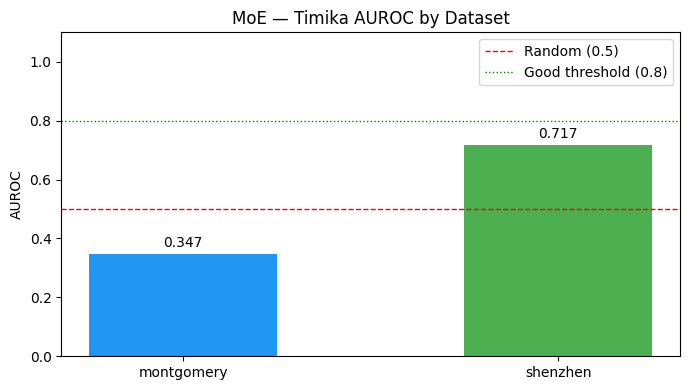

In [7]:
# ── Cell 7: Timika AUROC — MoE bar chart ─────────────────────────────────
import pandas as pd, matplotlib.pyplot as plt

sys_df = pd.read_csv(OUT_DIR / 'moe_system.csv')
auroc = sys_df[sys_df['metric']=='timika_auroc'].copy()
auroc = auroc[auroc['dataset'] != 'nih_cxr14']
auroc['value'] = pd.to_numeric(auroc['value'], errors='coerce')

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(auroc['dataset'], auroc['value'], color=['#2196F3','#4CAF50','#FF9800'], width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='red',   linestyle='--', linewidth=1, label='Random (0.5)')
ax.axhline(0.8, color='green', linestyle=':',  linewidth=1, label='Good threshold (0.8)')
ax.set_title('MoE — Timika AUROC by Dataset', fontsize=12)
ax.set_ylabel('AUROC')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'moe_timika_auroc.png', dpi=150)
plt.show()

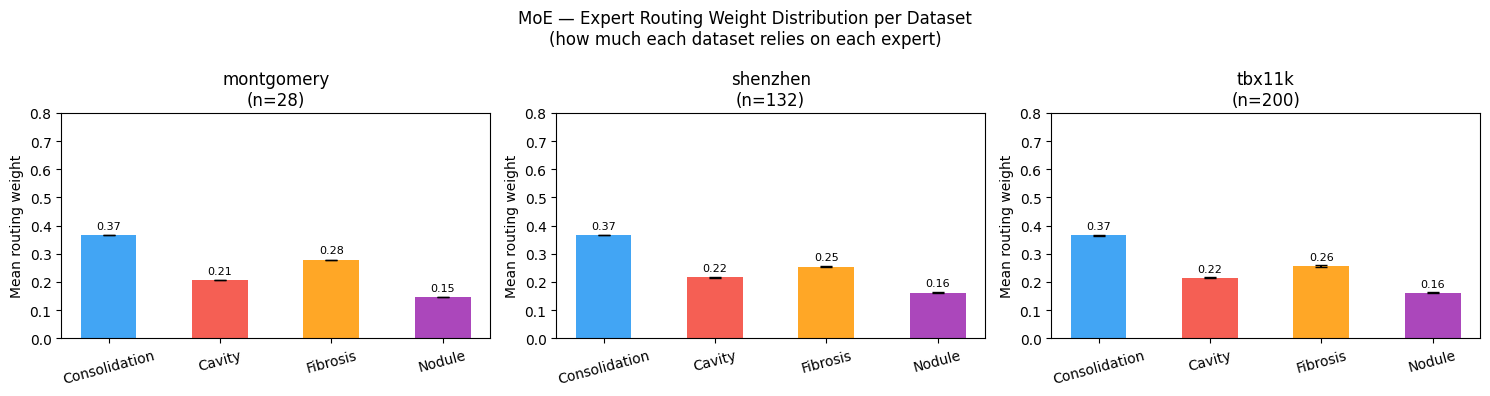

Saved: expert_routing_distribution.png


In [8]:
# ── Cell 8: Expert routing weight distribution ────────────────────────────
import pandas as pd, matplotlib.pyplot as plt, numpy as np

pi_df = pd.read_csv(OUT_DIR / 'moe_per_image.csv')
expert_cols = ['routing_consolidation','routing_cavity','routing_fibrosis','routing_nodule']
expert_labels = ['Consolidation','Cavity','Fibrosis','Nodule']
colors = ['#2196F3','#f44336','#FF9800','#9C27B0']

datasets = ['montgomery','shenzhen','tbx11k']
fig, axes = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 4), sharey=False)

for ax, dom in zip(axes, datasets):
    sub = pi_df[pi_df['dataset_id']==dom][expert_cols].dropna()
    means = sub.mean().values
    stds  = sub.std().values
    bars = ax.bar(expert_labels, means, color=colors, alpha=0.85, width=0.5)
    ax.errorbar(expert_labels, means, yerr=stds, fmt='none', color='black', capsize=4)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.set_ylim(0, 0.8)
    ax.set_title(f'{dom}\n(n={len(sub)})')
    ax.set_ylabel('Mean routing weight')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('MoE — Expert Routing Weight Distribution per Dataset\n'
             '(how much each dataset relies on each expert)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'expert_routing_distribution.png', dpi=150)
plt.show()
print('Saved: expert_routing_distribution.png')


=== MoE TB CLASSIFICATION ===
   dataset  accuracy  sensitivity  specificity   n
montgomery     0.500        1.000        0.000  28
  shenzhen     0.470        1.000        0.000 132
    tbx11k     0.000          NaN        0.000  82


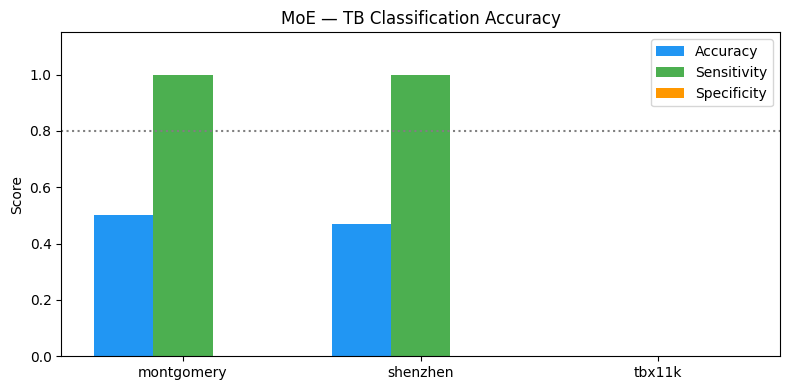

In [9]:
# ── Cell 9: TB classification accuracy ───────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt

pi_df = pd.read_csv(OUT_DIR / 'moe_per_image.csv')
pi_df = pi_df[pi_df['tb_label'].notna()].copy()
pi_df['tb_label'] = pi_df['tb_label'].astype(int)
pi_df['pred_positive'] = (pi_df['timika_score'] > 0).astype(int)

rows = []
for dom in ['montgomery','shenzhen','tbx11k']:
    sub = pi_df[pi_df['dataset_id']==dom]
    if sub.empty: continue
    tp = ((sub['pred_positive']==1)&(sub['tb_label']==1)).sum()
    tn = ((sub['pred_positive']==0)&(sub['tb_label']==0)).sum()
    fp = ((sub['pred_positive']==1)&(sub['tb_label']==0)).sum()
    fn = ((sub['pred_positive']==0)&(sub['tb_label']==1)).sum()
    sens = tp/(tp+fn) if (tp+fn)>0 else float('nan')
    spec = tn/(tn+fp) if (tn+fp)>0 else float('nan')
    acc  = (tp+tn)/len(sub)
    rows.append({'dataset':dom,'accuracy':acc,'sensitivity':sens,'specificity':spec,'n':len(sub)})

clf_df = pd.DataFrame(rows)
print('\n=== MoE TB CLASSIFICATION ===')
print(clf_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

x = np.arange(len(clf_df)); w=0.25
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w, clf_df['accuracy'],    width=w, label='Accuracy',    color='#2196F3')
ax.bar(x,   clf_df['sensitivity'], width=w, label='Sensitivity', color='#4CAF50')
ax.bar(x+w, clf_df['specificity'], width=w, label='Specificity', color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels(clf_df['dataset'])
ax.set_ylim(0,1.15)
ax.axhline(0.8, color='grey', linestyle=':')
ax.set_title('MoE — TB Classification Accuracy')
ax.set_ylabel('Score'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'moe_classification_accuracy.png', dpi=150)
plt.show()

In [ ]:
# ── Cell 10: Side-by-side comparison vs Baseline ─────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

BASELINE_DIR = Path('/kaggle/working/eval_baseline')

if not BASELINE_DIR.exists():
    print('Baseline results not found at', BASELINE_DIR)
    print('Run eval_baseline.ipynb first, then re-run this cell.')
else:
    bl_sys  = pd.read_csv(BASELINE_DIR / 'baseline_system.csv')
    moe_sys = pd.read_csv(OUT_DIR / 'moe_system.csv')

    bl_sys['value']  = pd.to_numeric(bl_sys['value'],  errors='coerce')
    moe_sys['value'] = pd.to_numeric(moe_sys['value'], errors='coerce')

    merged = bl_sys.merge(moe_sys, on=['metric','dataset'], suffixes=('_baseline','_moe'))
    merged['delta'] = merged['value_moe'] - merged['value_baseline']
    merged['pct_change'] = (merged['delta'] / merged['value_baseline'].abs() * 100).round(1)

    # Display AUROC and ALP rows — now including tb_head_auroc
    show = merged[merged['metric'].isin(['timika_auroc', 'tb_head_auroc', 'alp_mean'])].copy()
    show = show[show['dataset'] != 'nih_cxr14']
    show = show.sort_values(['metric', 'dataset'])

    print('\n=== BASELINE vs MoE — KEY METRICS ===')
    print(f'{"Metric":<22} {"Dataset":<13} {"Baseline":>10} {"MoE":>10} {"Delta":>8} {"Change":>8}')
    print('-' * 77)
    for _, row in show.iterrows():
        bl  = f"{row['value_baseline']:.4f}" if pd.notna(row['value_baseline']) else '  N/A'
        moe = f"{row['value_moe']:.4f}"      if pd.notna(row['value_moe'])      else '  N/A'
        d   = f"{row['delta']:+.4f}"          if pd.notna(row['delta'])          else '  N/A'
        pct = f"{row['pct_change']:+.1f}%"    if pd.notna(row['pct_change'])     else '  N/A'
        print(f"{row['metric']:<22} {row['dataset']:<13} {bl:>10} {moe:>10} {d:>8} {pct:>8}")

    # ── 3-panel comparison plot ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plot_metrics = [
        ('timika_auroc',  'Timika AUROC',        '#2196F3', '#607D8B'),
        ('tb_head_auroc', 'TB Head AUROC (Fix 1)', '#4CAF50', '#9E9E9E'),
        ('alp_mean',      'Mean ALP (%)',         '#FF9800', '#78909C'),
    ]
    for ax, (metric, label, moe_color, bl_color) in zip(axes, plot_metrics):
        sub = merged[merged['metric'] == metric].copy()
        sub = sub[sub['dataset'] != 'nih_cxr14'].dropna(subset=['value_baseline', 'value_moe'])
        if sub.empty:
            ax.text(0.5, 0.5, f'{label}\n(no data)', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label)
            continue
        x = np.arange(len(sub)); w = 0.35
        b1 = ax.bar(x - w/2, sub['value_baseline'], width=w, label='Baseline', color=bl_color,  alpha=0.85)
        b2 = ax.bar(x + w/2, sub['value_moe'],      width=w, label='MoE',      color=moe_color, alpha=0.85)
        ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=8)
        ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(sub['dataset'], rotation=10)
        if metric in ('timika_auroc', 'tb_head_auroc'):
            ax.set_ylim(0, 1.15)
            ax.axhline(0.5, color='red',   linestyle='--', linewidth=1, alpha=0.6, label='Random')
            ax.axhline(0.8, color='green', linestyle=':',  linewidth=1, alpha=0.6, label='Good')
        else:
            bot = max(0, sub[['value_baseline','value_moe']].min().min() * 0.85)
            ax.set_ylim(bot, sub[['value_baseline','value_moe']].max().max() * 1.15)
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=8)

    fig.suptitle('Baseline vs MoE — Key Metric Comparison', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'comparison_all.png', dpi=150)
    plt.show()
    print('Saved: comparison_all.png')

    comp_csv = OUT_DIR / 'baseline_vs_moe.csv'
    merged.to_csv(comp_csv, index=False)
    print(f'Saved: {comp_csv}')

In [ ]:
# ── Cell 10b: TB Head AUROC — MoE vs Baseline ────────────────────────────
# Fix 1 directly measured: sigmoid(tb_head(pooled)) = P(TB|image).
# AUROC > 0.5 means the trained TB head is better than random.
# AUROC ≈ 0.5 means the head is untrained (all outputs stuck at 0.5).
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

BASELINE_DIR = Path('/kaggle/working/eval_baseline')

moe_sys = pd.read_csv(OUT_DIR / 'moe_system.csv')
moe_tb  = moe_sys[moe_sys['metric'] == 'tb_head_auroc'].copy()
moe_tb['value'] = pd.to_numeric(moe_tb['value'], errors='coerce')
moe_tb = moe_tb[moe_tb['dataset'] != 'nih_cxr14']

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(moe_tb)); w = 0.35

if BASELINE_DIR.exists():
    bl_sys = pd.read_csv(BASELINE_DIR / 'baseline_system.csv')
    bl_tb  = bl_sys[bl_sys['metric'] == 'tb_head_auroc'].copy()
    bl_tb['value'] = pd.to_numeric(bl_tb['value'], errors='coerce')
    bl_tb = bl_tb[bl_tb['dataset'] != 'nih_cxr14']
    # Align on dataset
    merged_tb = bl_tb.merge(moe_tb, on='dataset', suffixes=('_bl','_moe'))
    if not merged_tb.empty:
        x = np.arange(len(merged_tb))
        b1 = ax.bar(x - w/2, merged_tb['value_bl'],  width=w, label='Baseline', color='#607D8B', alpha=0.85)
        b2 = ax.bar(x + w/2, merged_tb['value_moe'], width=w, label='MoE',      color='#4CAF50', alpha=0.85)
        ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=9)
        ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(merged_tb['dataset'])
else:
    # MoE only
    bars = ax.bar(moe_tb['dataset'], moe_tb['value'], color='#4CAF50', width=0.5, alpha=0.85, label='MoE')
    ax.bar_label(bars, fmt='%.3f', padding=3)

ax.set_ylim(0, 1.15)
ax.axhline(0.5, color='red',   linestyle='--', linewidth=1.2, label='Random (0.5)')
ax.axhline(0.8, color='green', linestyle=':',  linewidth=1.2, label='Good (0.8)')
ax.set_ylabel('AUROC')
ax.set_title('Fix 1 — TB Head AUROC: Direct P(TB|image) Classifier\n'
             '(trained binary BCE head on top of frozen DenseNet121)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'tb_head_auroc.png', dpi=150)
plt.show()
print('Saved: tb_head_auroc.png')

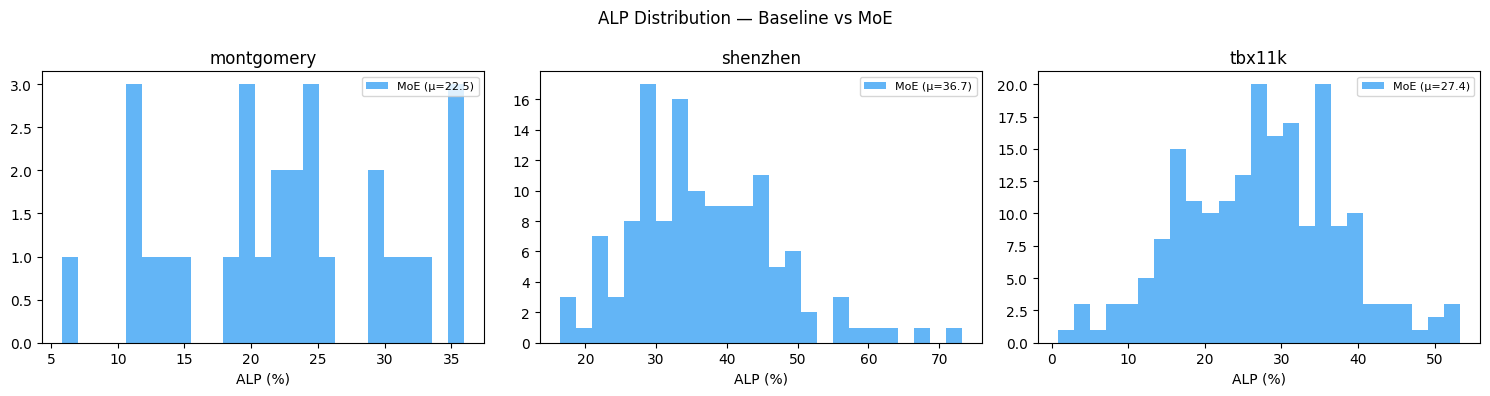

Saved: alp_comparison.png


In [11]:
# ── Cell 11: ALP distribution comparison ─────────────────────────────────
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

BASELINE_DIR = Path('/kaggle/working/eval_baseline')

moe_pi = pd.read_csv(OUT_DIR / 'moe_per_image.csv')

datasets = ['montgomery','shenzhen','tbx11k']
fig, axes = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 4))

for ax, dom in zip(axes, datasets):
    moe_alp = moe_pi[moe_pi['dataset_id']==dom]['alp'].dropna()
    ax.hist(moe_alp, bins=25, color='#2196F3', alpha=0.7, label=f'MoE (μ={moe_alp.mean():.1f})')

    if BASELINE_DIR.exists():
        bl_pi  = pd.read_csv(BASELINE_DIR / 'baseline_per_image.csv')
        bl_alp = bl_pi[bl_pi['dataset_id']==dom]['alp'].dropna()
        ax.hist(bl_alp, bins=25, color='#607D8B', alpha=0.5, label=f'Baseline (μ={bl_alp.mean():.1f})')

    ax.set_title(dom); ax.set_xlabel('ALP (%)')
    ax.legend(fontsize=8)

fig.suptitle('ALP Distribution — Baseline vs MoE', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'alp_comparison.png', dpi=150)
plt.show()
print('Saved: alp_comparison.png')

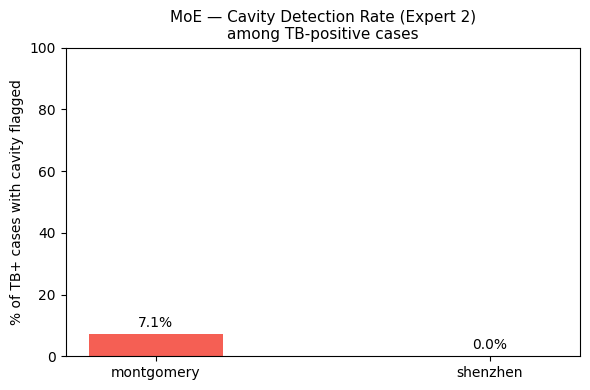

Saved: cavity_detection_rate.png


In [12]:
# ── Cell 12: Cavity detection rate (MoE only — Expert 2) ─────────────────
import pandas as pd, matplotlib.pyplot as plt

pi_df = pd.read_csv(OUT_DIR / 'moe_per_image.csv')
sys_df = pd.read_csv(OUT_DIR / 'moe_system.csv')
cav = sys_df[sys_df['metric']=='cavity_detection_rate'].copy()
cav['value'] = pd.to_numeric(cav['value'], errors='coerce')
cav = cav.dropna(subset=['value'])

if cav.empty:
    print('No cavity detection rate data (no TB-positive samples with TB labels).')
else:
    fig, ax = plt.subplots(figsize=(6,4))
    bars = ax.bar(cav['dataset'], cav['value']*100, color='#f44336', width=0.4, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_ylim(0, 100)
    ax.set_title('MoE — Cavity Detection Rate (Expert 2)\namong TB-positive cases', fontsize=11)
    ax.set_ylabel('% of TB+ cases with cavity flagged')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'cavity_detection_rate.png', dpi=150)
    plt.show()
    print('Saved: cavity_detection_rate.png')

In [13]:
# ── Cell 13: Final summary ────────────────────────────────────────────────
import json
from pathlib import Path

summary = json.loads((OUT_DIR / 'moe_summary.json').read_text())

print('=' * 60)
print('MoE EVALUATION — FINAL SUMMARY')
print('=' * 60)
print(f"  Images evaluated : {summary['counts']['ran_ok']}")
print(f"  Images skipped   : {summary['counts']['skipped']}")
print(f"  Device           : {summary['device']}")
print()
print('Output files saved to /kaggle/working/eval_moe/')
for name, path in summary['output_files'].items():
    print(f'  {name:<20}: {path}')
print('=' * 60)
print('\nDownload these files from the Kaggle Output tab.')

MoE EVALUATION — FINAL SUMMARY
  Images evaluated : 560
  Images skipped   : 0
  Device           : cuda:Tesla T4

Output files saved to /kaggle/working/eval_moe/
  components_csv      : /kaggle/working/eval_moe/moe_components.csv
  system_csv          : /kaggle/working/eval_moe/moe_system.csv
  per_image_csv       : /kaggle/working/eval_moe/moe_per_image.csv

Download these files from the Kaggle Output tab.
